# Anomaly Detection on Host and Kernel Events data (CICEVSE2024 dataset)

This notebook contains the implementation for detecting anomalies in EVSE HPC (Hardware Performance Counter) & Kernel events data using LSTM binary classification model. The implementation is done using open source Agno AI Agent. A multi-agent framework is implemented where each agent is responsible for a certain task. 4 Agents have been implemented for data loading & preprocessing, feature engineering, anomaly detection & report generation of the entire pipeline.
The detection agent uses a model LSTM Binary Classifier trained on BOTH benign and attack sequences.

## Flow diagram of Agent interfaction

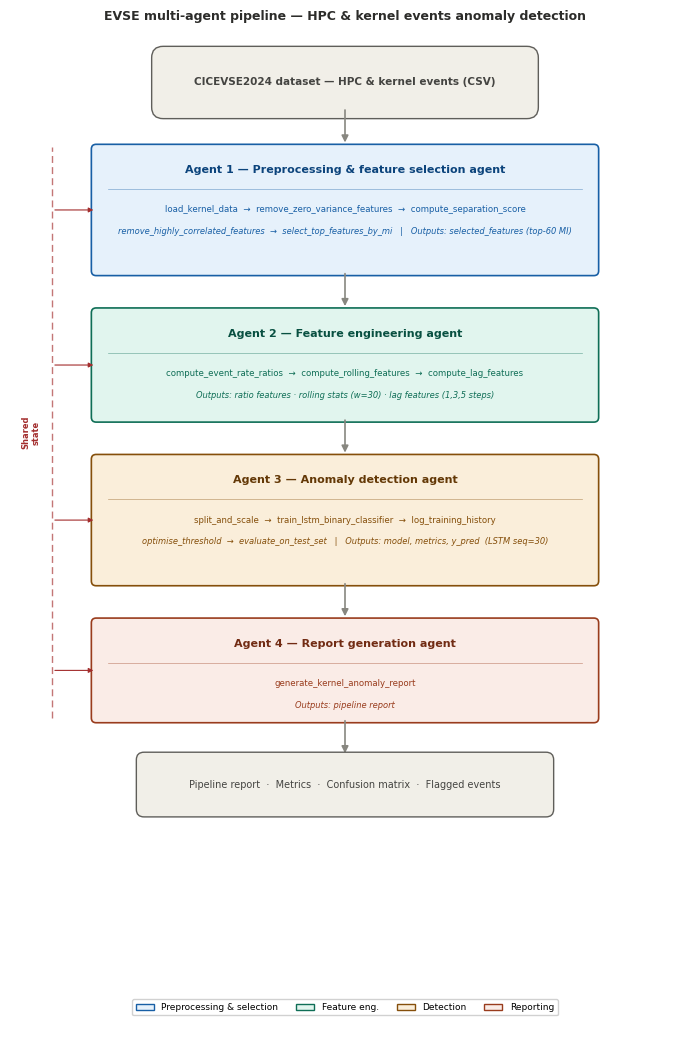

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(7, 10.5))
ax.set_xlim(0, 7)
ax.set_ylim(0, 10.5)
ax.axis("off")
fig.patch.set_facecolor("white")

# ── Colour palette ──────────────────────────────────────────────────────────
COLORS = {
    "blue":   {"face": "#E6F1FB", "edge": "#185FA5", "title": "#0C447C", "sub": "#185FA5"},
    "teal":   {"face": "#E1F5EE", "edge": "#0F6E56", "title": "#085041", "sub": "#0F6E56"},
    "amber":  {"face": "#FAEEDA", "edge": "#854F0B", "title": "#633806", "sub": "#854F0B"},
    "coral":  {"face": "#FAECE7", "edge": "#993C1D", "title": "#712B13", "sub": "#993C1D"},
    "gray":   {"face": "#F1EFE8", "edge": "#5F5E5A", "title": "#444441", "sub": "#5F5E5A"},
}

def draw_box(ax, x, y, w, h, label, tools, color_key, subtitle=None):
    """Draw an agent box with title, divider, tools line, and optional subtitle."""
    c = COLORS[color_key]
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                         facecolor=c["face"], edgecolor=c["edge"],
                         linewidth=1.2, zorder=2)
    ax.add_patch(box)
    ax.text(x + w / 2, y + h - 0.22, label,
            ha="center", va="center", fontsize=8, fontweight="bold",
            color=c["title"], zorder=3)
    ax.plot([x + 0.12, x + w - 0.12], [y + h - 0.42, y + h - 0.42],
            color=c["edge"], linewidth=0.5, alpha=0.5, zorder=3)
    ax.text(x + w / 2, y + h - 0.64, tools,
            ha="center", va="center", fontsize=6.2,
            color=c["sub"], zorder=3)
    if subtitle:
        ax.text(x + w / 2, y + h - 0.87, subtitle,
                ha="center", va="center", fontsize=6.0,
                color=c["sub"], style="italic", zorder=3)

def draw_arrow(ax, cx, y_start, y_end):
    ax.annotate("", xy=(cx, y_end), xytext=(cx, y_start),
                arrowprops=dict(arrowstyle="-|>", color="#888780",
                                lw=1.2, mutation_scale=10), zorder=2)

BOX_X, BOX_W = 0.9, 5.2
CX = BOX_X + BOX_W / 2

# ── Input node ──────────────────────────────────────────────────────────────
inp = FancyBboxPatch((1.6, 9.7), 3.8, 0.52,
                     boxstyle="round,pad=0.12",
                     facecolor=COLORS["gray"]["face"],
                     edgecolor=COLORS["gray"]["edge"],
                     linewidth=1.0, zorder=2)
ax.add_patch(inp)
ax.text(3.5, 9.96, "CICEVSE2024 dataset — HPC & kernel events (CSV)",
        ha="center", va="center", fontsize=7.5, fontweight="bold",
        color=COLORS["gray"]["title"], zorder=3)

draw_arrow(ax, CX, 9.70, 9.30)

# ── Agent 1: Preprocessing & Feature Selection ───────────────────────────────
draw_box(ax, BOX_X, 7.98, BOX_W, 1.28,
         "Agent 1 — Preprocessing & feature selection agent",
         "load_kernel_data  →  remove_zero_variance_features  →  compute_separation_score",
         "blue",
         subtitle="remove_highly_correlated_features  →  select_top_features_by_mi   |   Outputs: selected_features (top-60 MI)")

draw_arrow(ax, CX, 7.98, 7.58)

# ── Agent 2: Feature Engineering ────────────────────────────────────────────
draw_box(ax, BOX_X, 6.44, BOX_W, 1.10,
         "Agent 2 — Feature engineering agent",
         "compute_event_rate_ratios  →  compute_rolling_features  →  compute_lag_features",
         "teal",
         subtitle="Outputs: ratio features · rolling stats (w=30) · lag features (1,3,5 steps)")

draw_arrow(ax, CX, 6.44, 6.04)

# ── Agent 3: Anomaly Detection ───────────────────────────────────────────────
draw_box(ax, BOX_X, 4.72, BOX_W, 1.28,
         "Agent 3 — Anomaly detection agent",
         "split_and_scale  →  train_lstm_binary_classifier  →  log_training_history",
         "amber",
         subtitle="optimise_threshold  →  evaluate_on_test_set   |   Outputs: model, metrics, y_pred  (LSTM seq=30)")

draw_arrow(ax, CX, 4.72, 4.32)

# ── Agent 4: Report Generation ───────────────────────────────────────────────
draw_box(ax, BOX_X, 3.28, BOX_W, 1.00,
         "Agent 4 — Report generation agent",
         "generate_kernel_anomaly_report",
         "coral",
         subtitle="Outputs: pipeline report")

draw_arrow(ax, CX, 3.28, 2.88)

# ── Output node ──────────────────────────────────────────────────────────────
out = FancyBboxPatch((1.4, 2.32), 4.2, 0.52,
                     boxstyle="round,pad=0.08",
                     facecolor=COLORS["gray"]["face"],
                     edgecolor=COLORS["gray"]["edge"],
                     linewidth=1.0, zorder=2)
ax.add_patch(out)
ax.text(3.5, 2.58, "Pipeline report  ·  Metrics  ·  Confusion matrix  ·  Flagged events",
        ha="center", va="center", fontsize=7,
        color=COLORS["gray"]["title"], zorder=3)

# ── Shared state sidebar ──────────────────────────────────────────────────────
SX = 0.44
ax.plot([SX, SX], [3.28, 9.28], color="#A32D2D",
        linewidth=1.0, linestyle=(0, (5, 3)), alpha=0.65, zorder=2)

for ty in [8.62, 6.99, 5.36, 3.78]:
    ax.annotate("", xy=(BOX_X, ty), xytext=(SX, ty),
                arrowprops=dict(arrowstyle="-|>", color="#A32D2D",
                                lw=0.8, mutation_scale=7), zorder=2)

ax.text(0.22, 6.28, "Shared\nstate",
        ha="center", va="center", fontsize=6.0,
        color="#A32D2D", fontweight="bold",
        rotation=90, zorder=3)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=COLORS["blue"]["face"],  edgecolor=COLORS["blue"]["edge"],  label="Preprocessing & selection"),
    mpatches.Patch(facecolor=COLORS["teal"]["face"],  edgecolor=COLORS["teal"]["edge"],  label="Feature eng."),
    mpatches.Patch(facecolor=COLORS["amber"]["face"], edgecolor=COLORS["amber"]["edge"], label="Detection"),
    mpatches.Patch(facecolor=COLORS["coral"]["face"], edgecolor=COLORS["coral"]["edge"], label="Reporting"),
]
ax.legend(handles=legend_items, loc="lower center",
          ncol=4, fontsize=6.5, frameon=True,
          framealpha=0.9, edgecolor="#cccccc",
          bbox_to_anchor=(0.5, 0.01))

plt.title("EVSE multi-agent pipeline — HPC & kernel events anomaly detection",
          fontsize=9, fontweight="bold", color="#2C2C2A", pad=8)
plt.tight_layout()
plt.savefig("evse_hpc_pipeline_flow.pdf", bbox_inches="tight", dpi=300)
plt.savefig("evse_hpc_pipeline_flow.png", bbox_inches="tight", dpi=300)
plt.show()

## 1. Imports & Configuration

In [2]:
# Installing the required libraries.
# !pip install -U agno openai pandas numpy scikit-learn tensorflow matplotlib seaborn

In [3]:
import os
import json
import textwrap
import warnings
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, auc,
)
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from agno.agent import Agent
from agno.models.openai import OpenAIChat
from agno.tools import tool

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


/Users/rasikasonar/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/rasikasonar/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
DATA_PATH = "Dataset_for_masters_thesis/CICEVSE2024_Dataset/Host_Events/EVSE-B-HPC-Kernel-Events-Combined.csv"

In [5]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

## 2. Shared data between the agents.

To share the databetween the agents, we would be making use of dataclasses. Model parameters, preprocessed dataframes, selected features, sequences will be shared among the agents using this dataclass

In [6]:
@dataclass
class SharedDomainData:
    raw_df:               Optional[pd.DataFrame]  = None               # Raw dataframe loaded from CSV
    preprocessed_df:      Optional[pd.DataFrame]  = None               # Preprocessed dataframe from Agent 1
    label_col:            str                      = "Label"           # Target variable name
    time_col:             str                      = "time"            # Time column name
    scenario_col:         str                      = "Scenario"        # Stratification variable

    preprocessing_log:    List[str]               = field(default_factory=list)
    feature_log:          List[str]               = field(default_factory=list)
    detection_log:        List[str]               = field(default_factory=list)

    nonzero_var_cols:     List[str]               = field(default_factory=list)
    protected_cols:       List[str]               = field(default_factory=list)
    selected_features:    List[str]               = field(default_factory=list)

    ratio_cols:           List[str]               = field(default_factory=list)
    rolling_cols:         List[str]               = field(default_factory=list)
    lag_cols:             List[str]               = field(default_factory=list)
    all_feature_cols:     List[str]               = field(default_factory=list)

    scaler:               Optional[RobustScaler]  = None
    component_scaler:     Optional[StandardScaler]= None

    # ── Row-level splits (post scaling & pre-sequencing) ────────────────
    X_train:              Optional[np.ndarray]    = None
    X_val:                Optional[np.ndarray]    = None
    X_test:               Optional[np.ndarray]    = None
    y_train:              Optional[pd.Series]     = None
    y_val:                Optional[pd.Series]     = None
    y_test:               Optional[pd.Series]     = None
    train_idx:            Optional[np.ndarray]    = None
    val_idx:              Optional[np.ndarray]    = None
    test_idx:             Optional[np.ndarray]    = None

    # ── Sequence tensors fed into the LSTM Binary Classifier ────────────────
    X_train_seq:          Optional[np.ndarray]    = None
    X_val_seq:            Optional[np.ndarray]    = None
    X_test_seq:           Optional[np.ndarray]    = None
    y_train_seq:          Optional[np.ndarray]    = None
    y_val_seq:            Optional[np.ndarray]    = None
    y_test_seq:           Optional[np.ndarray]    = None
    train_seq_end_index:  Optional[np.ndarray]    = None
    val_seq_end_index:    Optional[np.ndarray]    = None
    test_seq_end_index:   Optional[np.ndarray]    = None

    y_pred:               Optional[np.ndarray]    = None
    scores:               Optional[np.ndarray]    = None

    seq_length:           int                     = 30

    # ── Model ───────────────────────────────────────────────────────────────
    model:                Optional[Any]           = None
    model_name:           Optional[str]           = None

    training_history:     Optional[Dict]          = None
    threshold:            Optional[float]         = None

    val_metrics:          Optional[Dict]          = None
    test_metrics:         Optional[Dict]          = None
    test_results_df:      Optional[pd.DataFrame]  = None

    report:               Optional[str]           = None
    epochs:               int                     = 300


In [7]:
state = SharedDomainData()

## 3. Tool Definitions

We will be defining the tools that agent will use in sequence to handle a specific task. 

### 3.1 Preprocessing & feature selection tools

In [8]:
# -----------------------------------------------------------------------------
# -------------Load data from filepath and encode Label, State-----------------
# -----------------------------------------------------------------------------
@tool
def load_kernel_data(filepath: str) -> str:
    """
    Load the EVSE kernel-event CSV dataset, sort by time, encode the label
    column (benign=0, attack=1). 

    Args:
        filepath: Path to the CSV file.

    Returns:
        File loading status.
    """
    df = pd.read_csv(filepath)

    # Rows after 6166 are faulty, truncate per dataset notes.
    df = df[:6166]
    state.preprocessing_log.append(f"Dataset loaded of shape {df.shape}\n")

    # Drop unnamed, metadata columns 
    unnamed = [c for c in df.columns if c.startswith("Unnamed")]
    meta    = ["interface", "Attack"]
    df.drop(columns=unnamed + meta, errors="ignore", inplace=True)
    state.preprocessing_log.append(f"Shape after dropping unnamed / interface / Attack columns: {df.shape}\n")

    # Deduplicate
    before = len(df)
    df.drop_duplicates(inplace=True)
    dupes = before - len(df)
    state.preprocessing_log.append(f"Duplicate rows removed: {dupes}")

    # Validate for missing values
    null_counts = int(df.isnull().sum().sum())
    state.preprocessing_log.append(f"Missing values in dataset: {null_counts}")

    df[state.time_col] = pd.to_numeric(df[state.time_col], errors="coerce")
    df.sort_values(state.time_col, inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Target variable encoding
    df[state.label_col] = df[state.label_col].map({"benign": 0, "attack": 1})

    # State encoding
    df["State"] = df["State"].map({"Charging": 1, "idle": 0})

    label_dist = df[state.label_col].value_counts().to_string()
    state.raw_df = df
    state.preprocessing_log.append(f"Label distribution:\n{label_dist}\n")

    if state.scenario_col in df.columns:
        scen_dist = df[state.scenario_col].value_counts().to_string()
        state.preprocessing_log.append(f"Scenario distribution (stratification key):\n{scen_dist}\n")

    return "Loaded HPC and kernel events data"


In [9]:
# -----------------------------------------------------------------------------
# ------------------Remove the zero variance features--------------------------
# -----------------------------------------------------------------------------
@tool
def remove_zero_variance_features() -> str:
    """
    Remove all columns with zero variance 
    """
    df = state.raw_df

    exclude = {state.time_col, state.label_col, state.scenario_col}
    candidate_cols = [c for c in df.columns if c not in exclude]

    X = df[candidate_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    selector = VarianceThreshold(threshold=0.0)
    selector.fit(X)

    keep_mask = selector.get_support()
    kept    = [c for c, k in zip(candidate_cols, keep_mask) if k]
    removed = [c for c, k in zip(candidate_cols, keep_mask) if not k]

    state.nonzero_var_cols = kept

    state.preprocessing_log.append(f"Zero-variance columns removed : {len(removed)}\n")
    state.preprocessing_log.append(f"Remaining feature columns     : {len(kept)}\n")
    return f"Removed {len(removed)} zero-variance columns; {len(kept)} remain."


##### We will calculate a separation score for all the features that have survived the variance filter. This step will help us identify if there is any feature that behaves differently in Attack vs Benign scenario. A feature that changes significantly during attack or benign scenario will help us identify in the next step where we drop the features that are highly colinear to each other.

In [10]:
# -----------------------------------------------------------------------------
# Calculate the separation score for the features that survived variance filter
# -----------------------------------------------------------------------------
@tool
def compute_separation_score() -> str:
    """
    For each surviving feature, compute a class separation score:
        separation = |mean_attack - mean_benign| / (std_benign + 1e-9)
    
    Returns:
        Top-20 features ranked by separation score.
    """
    df     = state.raw_df
    cols   = state.nonzero_var_cols
    y      = df["Label"]

    X = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    benign_mask = y == 0
    attack_mask = y == 1

    mean_benign = X[benign_mask].mean()
    mean_attack = X[attack_mask].mean()
    std_benign  = X[benign_mask].std()

    sep = ((mean_attack - mean_benign).abs() / (std_benign + 1e-9)).rename("separation")
    
    # This dataframe will store all the features from the feature list along with their separation score.
    profile = pd.DataFrame({
        "mean_benign" : mean_benign,
        "mean_attack" : mean_attack,
        "std_benign"  : std_benign,
        "separation"  : sep,
    }).sort_values("separation", ascending=False)

    state.separation_df = profile

    top20 = profile.head(20)[["mean_benign", "mean_attack", "separation"]].round(4)

    state.preprocessing_log.append("\nComputing separation score done. Top-20 features by class separation score are\n")
    state.preprocessing_log.append(f"\n{top20.to_string()}")    
    return "Computing separation score done. Top-20 features by class separation score are \n" + top20.to_string()

##### THe aim of this method is to identify the neighbouring features (by collinearilty) which are highly correlated to each other and keep the one having highest separation score while dropping the one having low separation score. This will make sure there are no redundant features in the training dataset and the features kep represent the best parameters of the EVSE.

In [11]:
# ---------------------------------------------------------------------------------------
# -------Remove highly correlated features by removing the best one for model training---
# ---------------------------------------------------------------------------------------
@tool
def remove_highly_correlated_features(correlation_threshold: float = 0.95) -> str:
    """
    When two features are highly correlated, the one with the LOWER separation
    score is dropped; the better-discriminating feature is kept.

    PROTECTED columns: both the numerator and denominator of every planned
    event-rate ratio are shielded from pruning regardless of correlation.
    This ensures Agent 2 can always compute its ratio features
    

    Args:
        correlation_threshold: Pearson |r| above which one feature is dropped.
                               Default 0.95.

    Returns:
        Summary of columns removed.
    """
    df   = state.raw_df
    cols = state.nonzero_var_cols

    X = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    # These columns indicate important characteristics of HPC and kernel events. 
    # These need to be used further for ratio features calculation.
    # Hence these features need to be protected from pruning
    ratio_pairs = [
        ("cache-misses",      "cache-references"),
        ("branch-misses",     "branch-loads"),
        ("dTLB-load-misses",  "instructions"),
        ("iTLB-load-misses",  "instructions"),
        ("br_mis_pred",       "br_pred"),
        ("context-switches",  "cpu-cycles"),
        ("instructions",      "cpu-cycles"),
    ]
    protected = set()
    for num, den in ratio_pairs:
        protected.add(num)
        protected.add(den)

    # Only protect what actually survived the variance filter
    protected = protected.intersection(set(cols))
    state.protected_cols = sorted(protected)

    # We will be looping through correlation matrix of the features however since the matrix contains
    # the variable twice, we will be refering to only the upper triange of the matrix
    corr_matrix = X.corr().abs()
    upper_tri   = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    sep_df = state.separation_df

    to_drop = set()
    for col in upper_tri.columns:
        partners = upper_tri.index[upper_tri[col] > correlation_threshold].tolist()
        for partner in partners:

            # If the feature or it's neighbour is in the protected list of columns, it will be kept.
            if col in protected or partner in protected:
                continue
            
            # if the existing column is having higher separation score that it's neighbour 
            # then the existing column will be kept and neighbour will be droped. 
            # Else neighbour will be kept and column will be lost
            sep_col     = sep_df.loc[col,     "separation"] if col     in sep_df.index else 0
            sep_partner = sep_df.loc[partner, "separation"] if partner in sep_df.index else 0
            if sep_col >= sep_partner:
                to_drop.add(partner)
            else:
                to_drop.add(col)

    after_cols = [c for c in cols if c not in to_drop]
    
    # List of columns remaining after going through the correlation check
    state.nonzero_var_cols = after_cols
    
    state.preprocessing_log.append(f"\nHighly correlated cols removed : {len(to_drop)}\n")
    state.preprocessing_log.append(f"\nRemaining columns.             : {len(after_cols)}\n")
    return f"{len(to_drop)} highly correlated columns are removed."

In [12]:
# -------------------------------------------------------------------
# -------Select the top_k features by using mutual Information-------
# -------------------------------------------------------------------
@tool
def select_top_features_by_mi(top_k: int = 60) -> str:
    """
    Rank all surviving features by Mutual Information (MI) with the binary
    label and select the top_k. MI captures non-linear dependencies and is
    more informative than linear correlation for kernel-event data.

    Args:
        top_k: Number of top features to retain. Default 60.

    Returns:
        No of features select by MI score
    """
    df   = state.raw_df
    cols = state.nonzero_var_cols
    y    = df["Label"]

    X = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    mi_scores = mutual_info_classif(X, y, discrete_features=False,
                                    n_neighbors=5, random_state=SEED)
    mi_series = pd.Series(mi_scores, index=cols).sort_values(ascending=False)

    selected = mi_series.head(top_k).index.tolist()
    state.selected_features = selected

    top_display = mi_series.head(30).round(6).to_string()
    
    state.preprocessing_log.append(f"\nTotal features ranked   : {len(cols)}\n")
    state.preprocessing_log.append(f"\nFeatures selected (top-{top_k}): {len(selected)}\n")
    state.preprocessing_log.append(f"\nTop-30 by Mutual Information:\n{top_display}")
    return f"Selected {len(selected)} features by Mutual Information"

### 3.2 Feature Engineering Tools  *(Agent 2)*

In [13]:
# -------------------------------------------------------------------------------------------------------------
# -------Compute the event rate ratios using the parameters that are significant to kernel event---------------
# -------------------------------------------------------------------------------------------------------------
@tool
def compute_event_rate_ratios() -> str:
    """
    Derive physics-informed event rate ratios from raw kernel-event counts.

    Raw counts are affected by workload intensity — a busy CPU always has more
    cache misses, branch instructions, etc.  Ratios normalise for this, making
    attack signatures visible even at low-intensity workloads.

    Returns:
        Number of ratio columns added.
    """
    df = state.raw_df.copy()

    ratio_defs = [
        ("cache-misses",      "cache-references", "ratio_cache_miss_rate"),
        ("branch-misses",     "branch-loads",      "ratio_branch_miss_rate"),
        ("dTLB-load-misses",  "instructions",      "ratio_dtlb_miss_per_inst"),
        ("iTLB-load-misses",  "instructions",      "ratio_itlb_miss_per_inst"),
        ("br_mis_pred",       "br_pred",           "ratio_br_mispred_rate"),
        ("context-switches",  "cpu-cycles",        "ratio_ctx_switch_per_cycle"),
        ("instructions",      "cpu-cycles",        "ratio_ipc"),
    ]

    added = []
    for num_col, den_col, new_name in ratio_defs:
        if num_col in df.columns and den_col in df.columns:
            num = pd.to_numeric(df[num_col], errors="coerce").fillna(0)
            den = pd.to_numeric(df[den_col], errors="coerce").fillna(0)
            df[new_name] = num / (den + 1e-9)
            added.append(new_name)

    state.raw_df    = df
    state.ratio_cols = added

    msg = (
        f"\nEvent rate ratio features added : {len(added)}"
        f"\nAdded features                : {added}"
    )
    
    state.feature_log.append(f"\nEvent rate ratio features added : {len(added)}")
    state.feature_log.append(f"\nAdded features                : {added}")
    return f"\nEvent rate ratio features added : {len(added)}"

In [14]:
# -------------------------------------------------------------------
# -----------Compute rolling features for time series data-----------
# -------------------------------------------------------------------
@tool
def compute_rolling_features(window_size: int = 30) -> str:
    """
    Compute rolling-window statistics (mean, std, max) over a sliding window
    of `window_size` rows (~seconds) for the top-20 MI-selected features.

    Rolling statistics encode HOW a metric has evolved recently, which is
    critical for detecting attack sequences that unfold over multiple seconds.

    Returns:
        Number of rolling features added and window size used.
    """
    df   = state.raw_df.copy()
    base = state.selected_features[:20]   # top-20 MI features
    stats = ["mean", "std", "max"]

    added = []
    for col in base:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").fillna(0)
        df[f"{col}_roll{window_size}_mean"] = s.rolling(window_size, min_periods=1).mean()
        df[f"{col}_roll{window_size}_std"]  = s.rolling(window_size, min_periods=1).std().fillna(0)
        df[f"{col}_roll{window_size}_max"]  = s.rolling(window_size, min_periods=1).max()
        added += [f"{col}_roll{window_size}_{st}" for st in stats]

    state.raw_df      = df
    state.rolling_cols = added

    state.feature_log.append(f"\nRolling window features added : {len(added)}\n")
    state.feature_log.append(f"\nAdded features                : {added}\n")
    return f"\nRolling window features added : {len(added)}\n"

In [15]:
# -------------------------------------------------------------------
# -----------Compute loag features for time series data--------------
# -------------------------------------------------------------------
@tool
def compute_lag_features() -> str:
    """
    Add lagged versions of the top-10 MI-selected features at 1, 3, and 5
    timestep offsets. Lag features give the LSTM direct access to recent
    history without relying entirely on its hidden state.

    Returns:
        Number of lag features added.
    """
    df       = state.raw_df.copy()
    base     = state.selected_features[:10]
    lag_steps = [1, 3, 5]

    added = []
    for col in base:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").fillna(0)
        for lag in lag_steps:
            new_col = f"{col}_lag{lag}"
            df[new_col] = s.shift(lag).fillna(0)
            added.append(new_col)

    state.raw_df   = df
    state.lag_cols = added

    msg = (
        f"\nLag features added : {len(added)}\n"
        f"\nAdded features     : {added}\n"
    )
    state.feature_log.append(msg)
    return msg

### 3.3 Detection Tools  *(Agent 3)*

The detection stage produces the train / validation / test split, packages the rows into sequences, trains the LSTM Binary Classifier, tunes the probability threshold on the validation set and evaluates on the held-out test set.

In [16]:
# -----------------------------------------------------------------------------
# ------Stratified shuffle split by Scenario (70 / 15 / 15)--------------------
# -----------------------------------------------------------------------------
@tool
def split_and_scale(
    train_ratio: float = 0.70,
    val_ratio:   float = 0.15,
    test_ratio:  float = 0.15,
    random_state: int  = SEED,
) -> str:
    """
    Stratified shuffle split on Scenario so every attack family (DoS, Recon,
    Cryptojacking) and the benign class are proportionally represented in
    train, validation and test. Within each split, rows are re-sorted by
    original index so local temporal structure (needed by rolling / lag
    features and LSTM sequences) is preserved.
    """
    df = state.raw_df.copy()

    # Assemble the full engineered feature matrix
    all_cols = (
        state.selected_features +
        state.ratio_cols +
        state.rolling_cols +
        state.lag_cols
    )
    # Deduplicate while preserving order
    seen = set()
    all_cols = [c for c in all_cols if not (c in seen or seen.add(c))]
    state.all_feature_cols = all_cols

    X = (df[all_cols]
             .apply(pd.to_numeric, errors="coerce")
             .replace([np.inf, -np.inf], np.nan)
             .fillna(0))
    y = df[state.label_col]

    # Stratification key: Scenario (fall back to Label if absent)
    if state.scenario_col in df.columns:
        strat = df[state.scenario_col].astype(str).fillna("Benign")
        strat_name = state.scenario_col
    else:
        strat = y.astype(str)
        strat_name = state.label_col

    # Merge tiny strata (<3) to avoid StratifiedShuffleSplit errors
    counts = strat.value_counts()
    rare   = counts[counts < 3].index.tolist()
    if rare:
        strat = strat.where(~strat.isin(rare), other="__rare__")

    # ── First split: train vs (val + test) ──────────────────────────────────
    sss1 = StratifiedShuffleSplit(
        n_splits=1, test_size=val_ratio + test_ratio, random_state=random_state
    )
    idx_train, idx_rest = next(sss1.split(X, strat))

    X_train_raw = X.iloc[idx_train]
    y_train     = y.iloc[idx_train]
    X_rest_raw  = X.iloc[idx_rest]
    y_rest      = y.iloc[idx_rest]
    strat_rest  = strat.iloc[idx_rest]

    # ── Second split: val vs test ───────────────────────────────────────────
    rel_test = test_ratio / (val_ratio + test_ratio)
    sss2 = StratifiedShuffleSplit(
        n_splits=1, test_size=rel_test, random_state=random_state
    )
    idx_val_rel, idx_test_rel = next(sss2.split(X_rest_raw, strat_rest))

    X_val_raw  = X_rest_raw.iloc[idx_val_rel]
    y_val      = y_rest.iloc[idx_val_rel]
    X_test_raw = X_rest_raw.iloc[idx_test_rel]
    y_test     = y_rest.iloc[idx_test_rel]

    # ── Re-sort each split by its original index so sequence construction
    #    preserves local temporal order. ─────────────────────────────────────
    def _sort_by_index(Xs, ys):
        order = Xs.index.argsort()
        return Xs.iloc[order], ys.iloc[order]

    X_train_raw, y_train = _sort_by_index(X_train_raw, y_train)
    X_val_raw,   y_val   = _sort_by_index(X_val_raw,   y_val)
    X_test_raw,  y_test  = _sort_by_index(X_test_raw,  y_test)

    # ── Fit RobustScaler on full training split ────────────────────────────
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw).astype(np.float32)
    X_val_scaled   = scaler.transform(X_val_raw).astype(np.float32)
    X_test_scaled  = scaler.transform(X_test_raw).astype(np.float32)
    state.scaler   = scaler

    # Store
    state.X_train, state.y_train = X_train_scaled, y_train
    state.X_val,   state.y_val   = X_val_scaled,   y_val
    state.X_test,  state.y_test  = X_test_scaled,  y_test
    state.train_idx = X_train_raw.index.to_numpy()
    state.val_idx   = X_val_raw.index.to_numpy()
    state.test_idx  = X_test_raw.index.to_numpy()

    # ── Logging ────────────────────────────────────────────────────────────
    def label_dist(s):
        vc = s.value_counts().to_dict()
        return {int(k): f"{v} ({v/len(s)*100:.1f}%)" for k, v in vc.items()}

    def scen_dist(split_idx):
        if strat_name not in df.columns:
            return "(stratification by Label)"
        sub = df.loc[split_idx, strat_name].astype(str)
        return {k: int(v) for k, v in sub.value_counts().to_dict().items()}

    state.detection_log.append(f"Split strategy : stratified shuffle by {strat_name}")
    state.detection_log.append(f"Train : {len(X_train_raw)} rows | Label dist {label_dist(y_train)}")
    state.detection_log.append(f"Val   : {len(X_val_raw)} rows | Label dist {label_dist(y_val)}")
    state.detection_log.append(f"Test  : {len(X_test_raw)} rows | Label dist {label_dist(y_test)}")
    state.detection_log.append(f"Train {strat_name} distribution: {scen_dist(state.train_idx)}")
    state.detection_log.append(f"Val   {strat_name} distribution: {scen_dist(state.val_idx)}")
    state.detection_log.append(f"Test  {strat_name} distribution: {scen_dist(state.test_idx)}")
    state.detection_log.append(
        f"RobustScaler fit on train only; Feature dim per timestep: {X_train_scaled.shape[1]}."
    )

    return (f"Stratified split by {strat_name} done. "
            f"Train/Val/Test sizes: {len(X_train_raw)}/{len(X_val_raw)}/{len(X_test_raw)}. "
            f"Feature dim: {X_train_scaled.shape[1]}.")


In [17]:
SEQUENCE_LENGTH = 30
# -----------------------------------------------------------------------------
# Create fixed-length sliding-window sequences from a 2D feature array.
# -----------------------------------------------------------------------------
def _create_sequences(X: np.ndarray,
                      y: Optional[np.ndarray] = None,
                      seq_length: int = SEQUENCE_LENGTH):
    """
    Build sliding-window sequences of shape (n_sequences, seq_length, n_features).
    The label of a sequence is the label of its LAST row.
    """
    if len(X) < seq_length:
        raise ValueError(
            f"Not enough rows ({len(X)}) to build sequences of length {seq_length}."
        )

    X_seq = np.array([X[i:i + seq_length] for i in range(len(X) - seq_length + 1)],
                     dtype=np.float32)
    if y is None:
        return X_seq, None
    y = np.asarray(y)
    y_seq = y[seq_length - 1:]
    return X_seq, y_seq


# -----------------------------------------------------------------------------
# ----- Train LSTM Binary Classifier on benign + attack sequences -------------
# -----------------------------------------------------------------------------
@tool
def train_lstm_binary_classifier(
    epochs: int = 300,
    batch_size: int = 64,
    hidden_dim: int = 64,
    latent_dim: int = 32,
    learning_rate: float = 1e-4,
    l2_reg: float = 1e-5,
    random_state: int = SEED,
) -> str:
    """
    Train a supervised LSTM binary classifier on sequences built from the
    training split. The training split contains BOTH benign (Label=0) and
    attack (Label=1) rows.

    Architecture:
        Input(SEQUENCE_LENGTH, n_features)
          - LSTM(hidden_dim, return_sequences=True, L2)  + Dropout
          - LSTM(latent_dim, return_sequences=False, L2) + Dropout
          - Dense(16, relu, L2)
          - Dense(1, sigmoid)

    """
    tf.keras.utils.set_random_seed(random_state)
    seq_length = SEQUENCE_LENGTH

    # ── Build sequences from the FULL train/val/test splits ────────────────
    X_train_seq, y_train_seq = _create_sequences(
        state.X_train, state.y_train.values, seq_length
    )
    X_val_seq, y_val_seq = _create_sequences(
        state.X_val, state.y_val.values, seq_length
    )
    X_test_seq, y_test_seq = _create_sequences(
        state.X_test, state.y_test.values, seq_length
    )

    # End-row original indices (for downstream reporting)
    train_end_idx = state.train_idx[seq_length - 1:]
    val_end_idx   = state.val_idx[seq_length - 1:]
    test_end_idx  = state.test_idx[seq_length - 1:]

    classes = np.unique(y_train_seq)
    if len(classes) < 2:
        raise ValueError(
            f"Training sequences contain only one class {classes}. "
            f"A supervised classifier needs both benign and attack examples."
        )

    n_features = X_train_seq.shape[2]
    reg = l2(l2_reg)

    # ── Define the binary classifier ──────────────────────────────────────
    inputs = Input(shape=(seq_length, n_features), name="input")
    x = LSTM(
        hidden_dim,
        activation="tanh",
        return_sequences=True,
        kernel_regularizer=reg,
        recurrent_regularizer=reg,
        name="lstm1",
    )(inputs)
    x = Dropout(0.3, name="drop1")(x)
    x = LSTM(
        latent_dim,
        activation="tanh",
        return_sequences=False,
        dropout=0.2,
        kernel_regularizer=reg,
        recurrent_regularizer=reg,
        name="lstm2",
    )(x)
    x = Dropout(0.3, name="drop2")(x)
    x = Dense(16, activation="relu", kernel_regularizer=reg, name="dense_hidden")(x)
    outputs = Dense(1, activation="sigmoid", name="output")(x)

    model = Model(inputs, outputs, name="LSTM_Binary_Classifier")
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    callbacks = [
        EarlyStopping(monitor="val_auc", mode="max",
                      patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=5, min_lr=1e-6, verbose=0),
    ]

    history = model.fit(
        X_train_seq,
        y_train_seq.astype(np.float32),
        validation_data=(X_val_seq, y_val_seq.astype(np.float32)),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        shuffle=False,
        verbose=0,
    )

    # Persist state
    state.model               = model
    state.model_name          = "LSTMBinaryClassifier"
    state.seq_length          = seq_length
    state.X_train_seq         = X_train_seq
    state.X_val_seq           = X_val_seq
    state.X_test_seq          = X_test_seq
    state.y_train_seq         = y_train_seq
    state.y_val_seq           = y_val_seq
    state.y_test_seq          = y_test_seq
    state.train_seq_end_index = train_end_idx
    state.val_seq_end_index   = val_end_idx
    state.test_seq_end_index  = test_end_idx
    state.training_history    = history.history

    def dist(y_arr):
        uniq = np.unique(y_arr)
        return {int(c): int((y_arr == c).sum()) for c in uniq}

    state.detection_log.append(f"Sequence length (pinned): {seq_length}")
    state.detection_log.append(f"LSTM Binary Classifier trained on benign+attack sequences: {X_train_seq.shape}")
    state.detection_log.append(f"Training   sequence label distribution: {dist(y_train_seq)}")
    state.detection_log.append(f"Validation sequence label distribution: {dist(y_val_seq)}")
    state.detection_log.append(f"Test       sequence label distribution: {dist(y_test_seq)}")
    state.detection_log.append(f"class_weight: disabled (attacks are the majority class)")
    state.detection_log.append(f"Optimiser Adam(lr={learning_rate}), L2={l2_reg}, dropout=0.3")
    state.detection_log.append(f"EarlyStopping on val_auc, patience=8, restore_best_weights=True")
    state.detection_log.append(f"Trainable parameters: {model.count_params():,}")

    return f"LSTM Binary Classifier trained on benign + attack sequences of length {seq_length}."


In [18]:
# -----------------------------------------------------------
# -----------Log the training history of the model-----------
# -----------------------------------------------------------
@tool
def log_training_history() -> str:
    """Summarise training history of the LSTM Binary Classifier."""
    if not state.training_history:
        return "No training history available — run train_lstm_binary_classifier first."

    hist          = state.training_history
    loss          = hist["loss"]
    val_loss      = hist["val_loss"]
    last_loss     = loss[-1]
    last_val_loss = val_loss[-1]

    if "val_auc" in hist and hist["val_auc"]:
        best_epoch = int(np.argmax(hist["val_auc"])) + 1
        best_src   = f"highest val_auc={max(hist['val_auc']):.4f}"
    else:
        best_epoch = int(np.argmin(val_loss)) + 1
        best_src   = f"lowest val_loss={min(val_loss):.6f}"

    state.detection_log.append(f"Training epochs: {len(loss)}")
    state.detection_log.append(f"Final train loss: {last_loss:.6f}")
    state.detection_log.append(f"Final val loss:   {last_val_loss:.6f}")
    state.detection_log.append(f"Best epoch ({best_src}): {best_epoch}")

    for key in ("val_accuracy", "val_precision", "val_recall", "val_auc"):
        if key in hist and hist[key]:
            state.detection_log.append(f"Final {key}: {hist[key][-1]:.4f}")

    return "Training history captured"


In [19]:
# -----------------------------------------------------------------------------
# ---Produce per-sequence attack probabilities from the classifier-------------
# -----------------------------------------------------------------------------
def _predict_probabilities(model, X_seq: np.ndarray) -> np.ndarray:
    """Return the model's predicted probability of class 1 (attack) per sequence."""
    probs = model.predict(X_seq, batch_size=256, verbose=0)
    return probs.ravel()


# -----------------------------------------------------------------------------
# ----Tune the decision threshold of the classifier on the validation set------
# -----------------------------------------------------------------------------
@tool
def optimise_threshold(optimise_for: str = "f1") -> str:
    """
    Find the probability threshold that maximises a chosen metric on the
    validation set. The anomaly score is the sigmoid probability of class 1
    (attack); higher means more likely attack.

    Args:
        optimise_for: Metric to maximise — 'f1', 'recall', or 'precision'
                      (default 'f1').

    Returns:
        Chosen threshold and corresponding validation metrics.
    """
    scores = _predict_probabilities(state.model, state.X_val_seq)
    y_val  = state.y_val_seq

    prec, rec, threshs = precision_recall_curve(y_val, scores)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)

    if len(threshs) == 0:
        best_thresh = 0.5
        state.detection_log.append(
            f"No thresholds returned from precision_recall_curve — defaulting to {best_thresh}"
        )
    else:
        if optimise_for == "f1":
            idx = int(np.argmax(f1s[:-1]))
        elif optimise_for == "recall":
            idx = int(np.argmax(rec[:-1]))
        elif optimise_for == "precision":
            idx = int(np.argmax(prec[:-1]))
        else:
            idx = int(np.argmax(f1s[:-1]))
        best_thresh = float(threshs[idx])
        state.detection_log.append(
            f"Predicted probability threshold {best_thresh:.6f} optimised for {optimise_for}"
        )

    state.threshold = best_thresh

    y_pred_val = (scores >= best_thresh).astype(int)
    metrics = {
        "threshold":  round(best_thresh, 6),
        "precision":  round(precision_score(y_val, y_pred_val, zero_division=0), 4),
        "recall":     round(recall_score(y_val,    y_pred_val, zero_division=0), 4),
        "f1":         round(f1_score(y_val,        y_pred_val, zero_division=0), 4),
    }
    state.val_metrics = metrics
    state.detection_log.append(f"Validation threshold optimisation completed. Val metrics: {metrics}")

    # ── Also compute F2 (recall-weighted) for reference ───────────────
    beta = 2.0
    f2s = ((1 + beta**2) * prec[:-1] * rec[:-1]) / (
        (beta**2) * prec[:-1] + rec[:-1] + 1e-12
    )
    if len(f2s) > 0 and np.any(np.isfinite(f2s)):
        f2_idx  = int(np.nanargmax(f2s))
        thr_f2  = float(threshs[f2_idx])
        p_f2    = float(prec[f2_idx])
        r_f2    = float(rec[f2_idx])
        f2_val  = float(f2s[f2_idx])
        state.detection_log.append(
            f"F2-optimal (reference only) threshold={thr_f2:.6f} "
            f"precision={p_f2:.4f} recall={r_f2:.4f} F2={f2_val:.4f}"
        )
    return "Optimised probability threshold chosen on the validation set."


In [20]:
# -------------------------------------------------
# -----------Evaluate on the test dataset----------
# -------------------------------------------------
@tool
def evaluate_on_test_set() -> str:
    """
    Apply the optimised probability threshold to the held-out test set and
    compute final evaluation metrics (precision, recall, F1, ROC-AUC, PR-AUC)
    plus a per-class classification report and confusion matrix.

    Returns:
        Status of evaluation on test set.
    """
    scores = _predict_probabilities(state.model, state.X_test_seq)
    state.scores = scores

    y_pred = (scores >= state.threshold).astype(int)
    state.y_pred = y_pred
    y_true = state.y_test_seq

    metrics = {
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_true,    y_pred, zero_division=0), 4),
        "f1":        round(f1_score(y_true,        y_pred, zero_division=0), 4),
        "roc_auc":   round(roc_auc_score(y_true, scores), 4),
        "pr_auc":    round(average_precision_score(y_true, scores), 4),
    }
    state.test_metrics = metrics

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
        fnr = fn / (fn + tp + 1e-9)
        fpr = fp / (fp + tn + 1e-9)
    else:
        fnr = fpr = float("nan")

    report_str = classification_report(
        y_true, y_pred, target_names=["Benign", "Attack"], digits=4, zero_division=0
    )

    # Keep a compact results dataframe for downstream reporting
    state.test_results_df = pd.DataFrame({
        "attack_probability": scores,
        "predicted":          y_pred,
        "actual":             y_true,
        "correct":            (y_pred == y_true).astype(int),
    })

    state.detection_log.append(f"Test metrics: {metrics}")
    state.detection_log.append(f"False Negative Rate (missed attacks): {fnr:.4f}")
    state.detection_log.append(f"False Positive Rate (false alarms):   {fpr:.4f}")
    state.detection_log.append(f"Classification Report:\n{report_str}")
    return "Evaluation completed on the test dataset."


### 3.4 Reporting Tool  *(Agent 4)*

In [21]:
# --------------------------------------------------------------
# ------------Generate report from all agent logs---------------
# --------------------------------------------------------------
@tool
def generate_kernel_anomaly_report() -> str:
    """
    Compile all pipeline results — profiling log, feature engineering log,
    detection log, validation metrics, test metrics, and per-class
    classification report / confusion matrix — into a structured plain-text
    report for human review.

    Returns:
        Report generation status.
    """
    sep  = "=" * 65
    sep2 = "-" * 65

    val  = state.val_metrics  or {}
    test = state.test_metrics or {}

    flagged_count = int(
        (state.test_results_df["predicted"] == 1).sum()
    ) if state.test_results_df is not None else "N/A"

    if state.y_test_seq is not None and state.y_pred is not None:
        cls_report = classification_report(
            state.y_test_seq, state.y_pred,
            target_names=["Benign", "Attack"], digits=4, zero_division=0,
        )
        cm = confusion_matrix(state.y_test_seq, state.y_pred)
        cm_str = (
            f"                 Predicted\n"
            f"                 Benign   Attack\n"
            f"Actual Benign   {cm[0,0]:>7}  {cm[0,1]:>7}\n"
            f"Actual Attack   {cm[1,0]:>7}  {cm[1,1]:>7}"
        )
    else:
        cls_report = "Classification report unavailable (no predictions)."
        cm_str     = "Confusion matrix unavailable (no predictions)."

    def section(title, lines):
        return f"\n{sep}\n  {title}\n{sep}\n" + "\n".join(lines) + "\n"

    header = textwrap.dedent(f"""\
    ╔══════════════════════════════════════════════════════════╗
    ║  EVSE Kernel-Event Anomaly Detection — Pipeline Report  ║
    ╚══════════════════════════════════════════════════════════╝

    MODEL USED: {state.model_name}
    DECISION THRESHOLD (probability of attack): {state.threshold}
    SEQUENCE LENGTH (pinned): {state.seq_length}
    """)

    lines = [header]
    lines.append(section("AGENT 1 — DATA PROFILING & FEATURE SELECTION",
                         state.preprocessing_log or ["No log available."]))
    lines.append(section("AGENT 2 — FEATURE ENGINEERING & WINDOWING",
                         state.feature_log or ["No log available."]))
    lines.append(section("AGENT 3 — LSTM BINARY CLASSIFIER DETECTION",
                         state.detection_log or ["No log available."]))

    metric_lines = [
        sep2,
        "  VALIDATION METRICS (threshold selection)",
        sep2,
        f"  Optimal threshold : {state.threshold:.6f}" if state.threshold else "  Threshold not set.",
        f"  Precision         : {val.get('precision', 'N/A')}",
        f"  Recall            : {val.get('recall',    'N/A')}",
        f"  F1                : {val.get('f1',        'N/A')}",
        "",
        sep2,
        "  TEST METRICS (held-out set)",
        sep2,
        f"  Precision         : {test.get('precision', 'N/A')}",
        f"  Recall            : {test.get('recall',    'N/A')}",
        f"  F1                : {test.get('f1',        'N/A')}",
        f"  AUC-ROC           : {test.get('roc_auc', 'N/A')}",
        f"  AUC-PR            : {test.get('pr_auc',  'N/A')}",
        "",
        sep2,
        "  PER-CLASS CLASSIFICATION REPORT (TEST)",
        sep2,
        cls_report,
        "",
        sep2,
        "  CONFUSION MATRIX (TEST)",
        sep2,
        cm_str,
        "",
        sep2,
        "  FLAGGED EVENTS (test set)",
        sep2,
        f"  Total anomalies flagged: {flagged_count}",
    ]
    lines.append(section("METRICS SUMMARY", metric_lines))

    state.report = "\n".join(lines)
    return "Report generated."


## 4. Agent Definitions

Each Agno `Agent` is given a curated subset of tools and a system prompt describing its  
role. The LLM backbone (GPT-4o-mini) autonomously decides the order and arguments of tool calls.

In [22]:
model = OpenAIChat(id="gpt-4o-mini", api_key=OPENAI_API_KEY, temperature=0.1)

In [23]:
preprocessing_agent = Agent(
    name="PreprocessingAgent",
    model=model,
    tools=[
        load_kernel_data,
        remove_zero_variance_features,
        compute_separation_score,
        remove_highly_correlated_features,
        select_top_features_by_mi
    ],
    instructions=[
        "You are a data preprocessing specialist for EVSE kernel-event data.",
        "Your job is to load the raw CSV, identify informative features, and produce a curated feature set.",
        "Always call tools in this exact order:",
        "  1. load_kernel_data           — load and sort the CSV; encode the label column.",
        "  2. remove_zero_variance_features — drop constant columns that carry no information.",
        "  3. compute_separation_score — compute per-feature class separation scores.",
        "  4. remove_highly_correlated_features  — remove redundant features using Pearson correlation.",
        "  5. select_top_features_by_mi  — rank survivors by Mutual Information and keep top-60.",
        "Do not skip any tool. Report findings clearly after each tool call.",
    ],
    markdown=False,
)

In [24]:
feature_agent = Agent(
    name="FeatureEngineeringAgent",
    model=model,
    tools=[
        compute_event_rate_ratios,
        compute_rolling_features,
        compute_lag_features
    ],
    instructions=[
        "You are a time-series feature engineering specialist for EVSE kernel-event anomaly detection.",
        "Your goal is to enrich the MI-selected features with domain-informed engineered features.",
        "Call all five tools in this order:",
        "  1. compute_event_rate_ratios  — normalise raw counts into ratios (e.g. cache miss rate, IPC).",
        "     Raw counts fluctuate with CPU load; ratios expose attack signatures at any load level.",
        "  2. compute_rolling_features   — add rolling mean/std/max over a 30-row sliding window.",
        "  3. compute_lag_features       — add 1-step, 3-step, and 5-step lags for temporal context.",
        "Report the number of features added in each step and the final sequence shapes.",
        "Do not skip any tool — each one is required for the pipeline to succeed.",
    ],
    markdown=False,
)

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Agent 3 — DetectionAgent
# Responsibility: stratified split + scale , train the LSTM Binary
#                 Classifier on benign+attack sequences, tune the probability
#                 threshold on validation, evaluate on the held-out test set.
# ─────────────────────────────────────────────────────────────────────────────
detection_agent = Agent(
    name="DetectionAgent",
    model=model,
    tools=[
        split_and_scale,
        train_lstm_binary_classifier,
        log_training_history,
        optimise_threshold,
        evaluate_on_test_set,
    ],
    instructions=[
        "You are an anomaly detection specialist for EVSE kernel-event cybersecurity data.",
        "Your goal is to detect attack events in EV charging station kernel logs using a supervised LSTM Binary Classifier.",
        "The classifier is trained on sequences labelled as benign (0) or attack (1).",
        "Sequence length is fixed at the module constant SEQUENCE_LENGTH (=30) and is NOT a tool argument. Do not pass seq_length.",
        "Call all five tools in order with their DEFAULT arguments unless a problem occurs:",
        "  1. split_and_scale             — stratified shuffle split by Scenario; fit RobustScaler on the training split only .",
        "  2. train_lstm_binary_classifier — Adam(1e-4), L2 + dropout, EarlyStopping on val_auc (patience 8).",
        "  3. log_training_history",
        "  4. optimise_threshold          — sweep probability thresholds on the validation set, optimise for F1.",
        "  5. evaluate_on_test_set        — apply the threshold to test and report all metrics.",
        "Report precision, recall, F1, AUC-ROC, AUC-PR, and highlight the false negative rate.",
        "Do not skip any tool — each one is required for the pipeline to succeed.",
    ],
    markdown=False,
)


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Agent 4 — ReportingAgent
# Responsibility: compile all pipeline logs and metrics into a structured
# plain-text report and provide an executive summary in plain English.
# ─────────────────────────────────────────────────────────────────────────────
reporting_agent = Agent(
    name="ReportingAgent",
    model=model,
    tools=[generate_kernel_anomaly_report],
    instructions=[
        "You are a reporting who generates reports of anomaly detection",
        "Call generate_kernel_anomaly_report to compile all pipeline results."
    ],
    markdown=False,
)

## 5. Run the Pipeline

Now we will be invoking each agent in sequence by providing appropriate prompts

### 5.1 — Preprocessing Agent

In [27]:
print("=" * 65)
print("STEP 1 — PreprocessingAgent")
print("=" * 65)

preprocessing_agent.print_response(
    f"Load and profile the EVSE kernel-event dataset at '{DATA_PATH}'. "
    "Remove zero-variance features, compute class separation scores, "
    "prune correlated features while protecting ratio-ingredient columns, "
    "and select the top-60 features by Mutual Information."
)

STEP 1 — PreprocessingAgent


Output()

### 5.2 — FeatureEngineeringAgent

In [28]:
print("=" * 65)
print("STEP 2 — FeatureEngineeringAgent")
print("=" * 65)

feature_agent.print_response(
    "Engineer features from the profiled EVSE kernel-event data. "
    "Derive event-rate ratios, 30-row rolling statistics, and 1/3/5-step lag features. "
)

STEP 2 — FeatureEngineeringAgent


Output()

### 5.3 — DetectionAgent

In [29]:
print("=" * 65)
print("STEP 3 — DetectionAgent")
print("=" * 65)

detection_agent.print_response(
    "Execute the detection pipeline for the EVSE kernel-event data. "
    "Use split_and_scale to produce a stratified train/val/test split by Scenario, "
    "with the RobustScaler fit on the training split only. "
    "Train the LSTM Binary Classifier using its default arguments — do not pass any "
    "sequence length; the sequence length is pinned at the module constant SEQUENCE_LENGTH=30. "
    "Optimise the probability threshold for F1 on the validation set. "
    "Evaluate on the test set and report precision, recall, F1, ROC-AUC, PR-AUC, "
    "and highlight the false negative rate."
)


STEP 3 — DetectionAgent


Output()

WARNING:absl:At this time, the v2.11+ optimizer `tf.keras.optimizers.Adam` runs slowly on M1/M2 Macs, please use 
the legacy Keras optimizer instead, located at `tf.keras.optimizers.legacy.Adam`.

### 5.4 — ReportingAgent

In [30]:
print("=" * 65)
print("STEP 4 — ReportingAgent")
print("=" * 65)

reporting_agent.print_response(
    "Generate the full anomaly detection report for the EVSE kernel-event pipeline. "
)

STEP 4 — ReportingAgent


Output()

---
## 6. Inspect Results Programmatically

In [31]:
# ── Print full text report ────────────────────────────────────────────────────
if state.report:
    print(state.report)
    with open("Anomaly_Detection_Hpc_Kernel_Events_Report.txt", "w") as f:
        f.write(state.report)

╔══════════════════════════════════════════════════════════╗
║  EVSE Kernel-Event Anomaly Detection — Pipeline Report  ║
╚══════════════════════════════════════════════════════════╝

MODEL USED: LSTMBinaryClassifier
DECISION THRESHOLD (probability of attack): 0.9846863746643066
SEQUENCE LENGTH (pinned): 30


  AGENT 1 — DATA PROFILING & FEATURE SELECTION
Dataset loaded of shape (6166, 915)

Shape after dropping unnamed / interface / Attack columns: (6166, 909)

Duplicate rows removed: 0
Missing values in dataset: 0
Label distribution:
Label
1    3864
0    2302

Scenario distribution (stratification key):
Scenario
Benign           2302
Cryptojacking    1793
Recon            1206
DoS               865

Zero-variance columns removed : 685

Remaining feature columns     : 221


Computing separation score done. Top-20 features by class separation score are


                                mean_benign  mean_attack    separation
fib_fib_table_lookup                    0.0   34589.5406  3.458

## Loss Curve

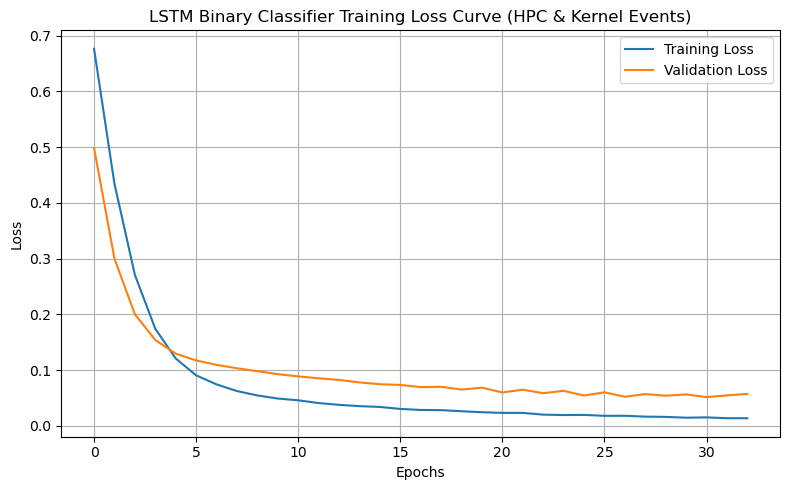

In [32]:
plt.figure(figsize=(8, 5))
loss = state.training_history['loss']
val_loss = state.training_history["val_loss"]
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Binary Classifier Training Loss Curve (HPC & Kernel Events)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Confusion Matrix

In [33]:
cm = confusion_matrix(state.y_test_seq, state.y_pred)
print(cm)


[[345   1]
 [ 23 527]]


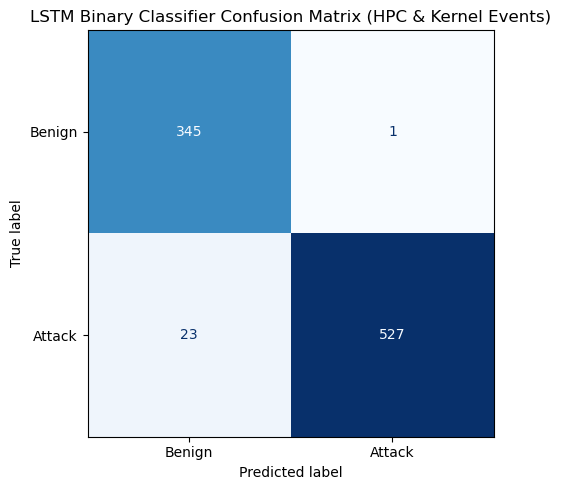

In [34]:
cm = confusion_matrix(state.y_test_seq, state.y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title("LSTM Binary Classifier Confusion Matrix (HPC & Kernel Events)")
plt.tight_layout()
plt.show()


## ROC curve

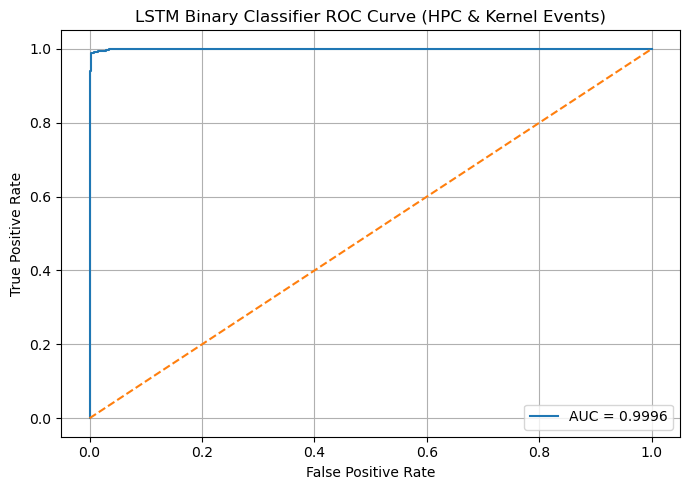

In [35]:
fpr, tpr, _ = roc_curve(state.y_test_seq, state.scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM Binary Classifier ROC Curve (HPC & Kernel Events)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


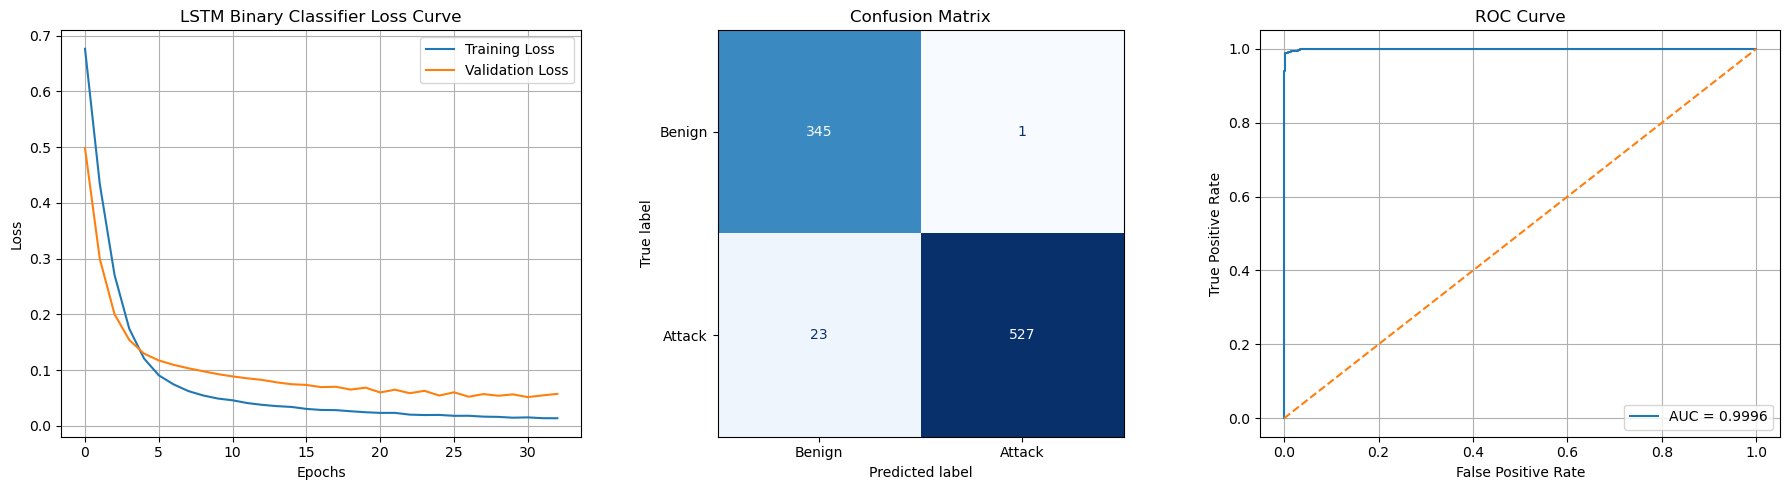

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
loss = state.training_history['loss']
val_loss = state.training_history["val_loss"]
axes[0].plot(loss, label='Training Loss')
axes[0].plot(val_loss, label='Validation Loss')
axes[0].set_title('LSTM Binary Classifier Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Confusion matrix
cm = confusion_matrix(state.y_test_seq, state.y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues', ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(state.y_test_seq, state.scores)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
axes[2].plot([0, 1], [0, 1], linestyle='--')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right')
axes[2].grid(True)

plt.tight_layout()
plt.show()
